<a href="https://colab.research.google.com/github/jonasknoll57/Bachelorarbeit_Demand-AD/blob/main/V10_Transfer_MA_HD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# V10 — Cross-City Transfer Learning: Mannheim -> Heidelberg

**Forschungsfrage:** Inwieweit lässt sich Wissen zur Erkennung von Nachfrage-Anomalien in stationsbasierten Bike-Sharing-Systemen mittels Cross-City Transfer Learning von datenreichen auf datenarme Städte übertragen?

## Experimentdesign

| Phase | Experiment | Beschreibung |
|---|---|---|
| 0 | Heidelberg Cleaning | Cleaning analog zu Mannheim |
| 1 | Source-Modell (Mannheim) | E1-Pipeline auf Mannheim -> trainiertes AE-Modell |
| 2 | Target-Baseline (Heidelberg) | E1-Pipeline auf Heidelberg mit 100% Daten -> Vergleichsbasis |
| 3 | Zero-Shot Transfer | Mannheim-Modell direkt auf Heidelberg (ohne Fine-Tuning) |
| 4 | Fine-Tuning Transfer | Pre-Train Mannheim -> Fine-Tune mit k% Heidelberg-Daten |
| 5 | Data-Scarcity Baseline | Heidelberg-only Modell mit k% Daten (ohne Transfer) |
| 6 | Vergleich & Visualisierung | Alle Ansätze gegenüberstellen |

**Basis-Setup:** E1 (Gap-Fill, Contiguous, absolute Features, StandardScaler pro Stadt)

**Normalisierungsstrategie (Transfer-kritisch):**
- StandardScaler wird **pro Stadt** auf deren Trainingsdaten gefittet
- Zeitfeatures (hour_sin, dow_cos etc.) sind ohnehin skaleninvariant
- Beim Zero-Shot: Heidelberg-Scaler auf die wenigen verfügbaren Daten fitten
- Beim Fine-Tuning: Scaler auf Heidelberg-Trainingsdaten anpassen


In [1]:
# ══════════════════════════════════════════════════════════════
# 0a — Colab Setup
# ══════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# ══════════════════════════════════════════════════════════════
# 0b — Imports, Seeds, Config
# ══════════════════════════════════════════════════════════════
import os, math, json, random, warnings, time, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dataclasses import dataclass, field, asdict
from typing import List, Optional, Tuple
from copy import deepcopy
from collections import defaultdict

from scipy.stats import poisson
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    precision_recall_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

# Reproduzierbarkeit
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TF version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")


TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ══════════════════════════════════════════════════════════════
# 0c — Konfiguration
# ══════════════════════════════════════════════════════════════
@dataclass
class TransferConfig:
    # Städte
    source_city: str = "Mannheim"
    target_city: str = "Heidelberg"

    # Basis = E1 (bestes Setup aus V9.2)
    aggregation_minutes: int = 60
    train_ratio: float = 0.67
    val_ratio: float = 0.82

    min_events_per_day: float = 3.0
    rolling_days: int = 56
    min_context_obs: int = 20

    # AE Architektur (E1)
    ae_window_size: int = 24
    ae_latent_dim: int = 32
    ae_layers: int = 2
    ae_dropout: float = 0.1

    # AE Training
    ae_epochs: int = 50
    ae_batch_size: int = 2048
    ae_lr: float = 1e-3
    ae_early_stop: int = 8

    # Fine-Tuning spezifisch
    ft_epochs: int = 30
    ft_lr: float = 1e-4           # niedrigere LR für Fine-Tuning
    ft_early_stop: int = 6
    ft_freeze_encoder: bool = False  # Optional: Encoder einfrieren

    # Thresholds
    threshold_quantile_station: float = 0.99
    threshold_quantile_group: float = 0.99

    # Demand-Regime
    low_demand_q: float = 0.33
    high_demand_q: float = 0.67

    # Experiment Flags (E1)
    use_gap_fill: bool = True
    require_contiguous: bool = True
    use_relative_features: bool = False
    use_bidirectional: bool = False

    # Features (E1)
    ae_features: List[str] = field(default_factory=lambda: [
        "n_lends", "n_returns",
        "hour_sin", "hour_cos",
        "dow_sin", "dow_cos",
        "month_sin", "month_cos",
        "is_weekend"
    ])
    ae_score_features: List[str] = field(default_factory=lambda: [
        "n_lends", "n_returns"
    ])

    # Data Scarcity: Anteile der Heidelberg-Daten für Fine-Tuning
    scarcity_ratios: List[float] = field(default_factory=lambda: [
        0.01, 0.05, 0.10, 0.25, 0.50, 1.0
    ])

cfg = TransferConfig()
print("Transfer-Config:")
for k, v in asdict(cfg).items():
    print(f"  {k}: {v}")


Transfer-Config:
  source_city: Mannheim
  target_city: Heidelberg
  aggregation_minutes: 60
  train_ratio: 0.67
  val_ratio: 0.82
  min_events_per_day: 3.0
  rolling_days: 56
  min_context_obs: 20
  ae_window_size: 24
  ae_latent_dim: 32
  ae_layers: 2
  ae_dropout: 0.1
  ae_epochs: 50
  ae_batch_size: 2048
  ae_lr: 0.001
  ae_early_stop: 8
  ft_epochs: 30
  ft_lr: 0.0001
  ft_early_stop: 6
  ft_freeze_encoder: False
  threshold_quantile_station: 0.99
  threshold_quantile_group: 0.99
  low_demand_q: 0.33
  high_demand_q: 0.67
  use_gap_fill: True
  require_contiguous: True
  use_relative_features: False
  use_bidirectional: False
  ae_features: ['n_lends', 'n_returns', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend']
  ae_score_features: ['n_lends', 'n_returns']
  scarcity_ratios: [0.01, 0.05, 0.1, 0.25, 0.5, 1.0]


In [4]:
# ══════════════════════════════════════════════════════════════
# 0d — Pfade
# ══════════════════════════════════════════════════════════════
DATA_BASE    = '/content/drive/MyDrive/BA_Colab/data'
CLEANED_BASE = '/content/drive/MyDrive/BA_Colab/cleaned'
RESULTS_DIR  = f'{DATA_BASE}/v10_transfer_results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Source (Mannheim) — bereits gecleaned
source_demand_path = f'{CLEANED_BASE}/demand/{cfg.source_city}/demand_cleaned.parquet'
source_geo_path    = f'{CLEANED_BASE}/geo_information/geo_information.parquet'

# Target (Heidelberg) — wird in Phase 0 gecleaned
target_raw_demand_dir = f'{DATA_BASE}/demand/{cfg.target_city}'
target_demand_path    = f'{CLEANED_BASE}/demand/{cfg.target_city}/demand_cleaned.parquet'

# Station Names (shared)
station_names_path = f'{DATA_BASE}/station_names/station_names.parquet'

print(f"Source: {source_demand_path}")
print(f"Target raw: {target_raw_demand_dir}")
print(f"Target cleaned: {target_demand_path}")
print(f"Results: {RESULTS_DIR}")


Source: /content/drive/MyDrive/BA_Colab/cleaned/demand/Mannheim/demand_cleaned.parquet
Target raw: /content/drive/MyDrive/BA_Colab/data/demand/Heidelberg
Target cleaned: /content/drive/MyDrive/BA_Colab/cleaned/demand/Heidelberg/demand_cleaned.parquet
Results: /content/drive/MyDrive/BA_Colab/data/v10_transfer_results


---
## Phase 0 — Heidelberg Cleaning

Identische Cleaning-Logik wie Mannheim:
1. Nur `station_type='real'` behalten
2. Stationen mit max. Datenlücke > 90 Tage entfernen
3. Fehlende Tage auf Stadtebene entfernen


In [5]:
# ══════════════════════════════════════════════════════════════
# Phase 0 — Heidelberg Cleaning
# ══════════════════════════════════════════════════════════════
import pyarrow.parquet as pq

CITY_TARGET = cfg.target_city

# ── Station-Typ Klassifikation ──
def classify_station(name):
    if not isinstance(name, str) or name.strip() == '':
        return 'unknown'
    n = name.strip()
    if re.search(r'(?i)^recording[_\-\s]', n): return 'recording'
    if re.match(r'(?i)^bike[-_]?\s*\d*', n):   return 'bike'
    if re.search(r'(?i)(virtuell|virtual)', n): return 'virtual'
    if re.fullmatch(r'[\d\s\-_\.#/]+', n):     return 'only_nums'
    return 'real'

station_names_raw = pd.read_parquet(station_names_path)
station_names_raw = station_names_raw.rename(
    columns={'id': 'station_name_id', 'name': 'station_name'}
)
station_names_raw['station_type'] = station_names_raw['station_name'].apply(classify_station)
type_lookup = station_names_raw.set_index('station_name_id')['station_type'].to_dict()

print(f'╔══════════════════════════════════════════════════╗')
print(f'║  CLEANING — {CITY_TARGET}                        ║')
print(f'╚══════════════════════════════════════════════════╝')

# ── Laden ──
files = glob.glob(f'{target_raw_demand_dir}/**/*.parquet', recursive=True)
if not files:
    files = glob.glob(f'{target_raw_demand_dir}/*.parquet')
print(f'  Parquet-Dateien: {len(files)}')

cols = ['network_name', 'timestamp', 'station_id', 'station_name_id',
        'location_id', 'n_lends', 'n_returns']
demand_hd = pd.concat(
    [pd.read_parquet(f, columns=cols) for f in files],
    ignore_index=True
)
demand_hd['timestamp']    = pd.to_datetime(demand_hd['timestamp'], utc=True)
demand_hd['station_type'] = demand_hd['station_name_id'].map(type_lookup).fillna('unknown')
demand_hd['total_demand'] = demand_hd['n_lends'] + demand_hd['n_returns']
print(f'  Roh: {len(demand_hd):,} Zeilen, {demand_hd["station_id"].nunique()} Stationen')

# [1] Nur real
before = len(demand_hd)
demand_hd = demand_hd[demand_hd['station_type'] == 'real'].copy()
print(f'  [1] Nur real: {len(demand_hd):,} (entfernt: {before-len(demand_hd):,}) '
      f'| {demand_hd["station_id"].nunique()} Stationen')

# [2] Max Gap > 90 Tage entfernen
demand_hd['date'] = demand_hd['timestamp'].dt.date

def max_gap(dates):
    s = sorted(set(pd.to_datetime(d) for d in dates))
    if len(s) < 2: return 0
    return max((s[i+1] - s[i]).days - 1 for i in range(len(s)-1))

station_gaps = (
    demand_hd.groupby('station_id')['date']
    .apply(max_gap).reset_index()
    .rename(columns={'date': 'max_gap_days'})
)
bad = station_gaps[station_gaps['max_gap_days'] > 90]['station_id'].tolist()
demand_hd = demand_hd[~demand_hd['station_id'].isin(bad)].copy()
print(f'  [2] Lücke >90d entfernt: {len(bad)} Stationen')
print(f'       Verbleibend: {demand_hd["station_id"].nunique()} Stationen, {len(demand_hd):,} Zeilen')

# [3] Fehlende Tage auf Stadtebene
daily = demand_hd.groupby('date')['total_demand'].sum().reset_index()
all_dates = pd.date_range(
    demand_hd['timestamp'].min().date(),
    demand_hd['timestamp'].max().date(), freq='D'
)
existing = set(pd.Timestamp(d) for d in daily['date'])
missing = [d for d in all_dates if d not in existing]

if missing:
    miss_set = {d.date() for d in missing}
    demand_hd = demand_hd[~demand_hd['date'].isin(miss_set)].copy()
    print(f'  [3] Fehlende Tage entfernt: {len(missing)}')
else:
    print(f'  [3] Keine fehlenden Tage.')

demand_hd = demand_hd.drop(columns=['station_type', 'total_demand', 'date'])

# Speichern
out_dir = f'{CLEANED_BASE}/demand/{CITY_TARGET}'
os.makedirs(out_dir, exist_ok=True)
demand_hd.to_parquet(f'{out_dir}/demand_cleaned.parquet', index=False)

print(f'\n  ✅ {CITY_TARGET} gecleaned: {len(demand_hd):,} Zeilen, '
      f'{demand_hd["station_id"].nunique()} Stationen')
print(f'  Pfad: {out_dir}/demand_cleaned.parquet')


╔══════════════════════════════════════════════════╗
║  CLEANING — Heidelberg                        ║
╚══════════════════════════════════════════════════╝
  Parquet-Dateien: 36
  Roh: 1,957,371 Zeilen, 79748 Stationen
  [1] Nur real: 1,873,100 (entfernt: 84,271) | 70 Stationen
  [2] Lücke >90d entfernt: 0 Stationen
       Verbleibend: 70 Stationen, 1,873,100 Zeilen
  [3] Fehlende Tage entfernt: 1

  ✅ Heidelberg gecleaned: 1,873,100 Zeilen, 70 Stationen
  Pfad: /content/drive/MyDrive/BA_Colab/cleaned/demand/Heidelberg/demand_cleaned.parquet


---
## Shared Functions (aus V9.2 übernommen)

Alle Kernfunktionen der AD-Pipeline. Identisch zu V9.2 E1.


In [6]:
# ══════════════════════════════════════════════════════════════
# 1 — Aggregation
# ══════════════════════════════════════════════════════════════
def aggregate_station_level(df: pd.DataFrame, minutes: int = 60,
                            add_relative: bool = False) -> pd.DataFrame:
    out = df.copy()
    freq = f"{minutes}min"
    out["time_bin"] = out["timestamp"].dt.floor(freq)

    agg = (
        out.groupby(
            ["station_id", "station_name_id", "station_name", "location_id", "time_bin"],
            as_index=False
        )
        .agg({
            "n_lends": "sum",
            "n_returns": "sum",
            "latitude": "first",
            "longitude": "first"
        })
        .rename(columns={"time_bin": "hour_ts"})
    )

    agg["total_demand"] = agg["n_lends"] + agg["n_returns"]
    agg["net_flow"] = agg["n_returns"] - agg["n_lends"]
    agg["abs_net_flow"] = agg["net_flow"].abs()

    agg["hour"] = agg["hour_ts"].dt.hour
    agg["dow"] = agg["hour_ts"].dt.dayofweek
    agg["month"] = agg["hour_ts"].dt.month
    agg["is_weekend"] = agg["dow"].isin([5, 6]).astype(int)

    agg["hour_sin"] = np.sin(2 * np.pi * agg["hour"] / 24)
    agg["hour_cos"] = np.cos(2 * np.pi * agg["hour"] / 24)
    agg["dow_sin"]  = np.sin(2 * np.pi * agg["dow"] / 7)
    agg["dow_cos"]  = np.cos(2 * np.pi * agg["dow"] / 7)
    agg["month_sin"] = np.sin(2 * np.pi * (agg["month"] - 1) / 12)
    agg["month_cos"] = np.cos(2 * np.pi * (agg["month"] - 1) / 12)

    agg = agg.sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    return agg


In [7]:
# ══════════════════════════════════════════════════════════════
# 2 — Gap-Fill
# ══════════════════════════════════════════════════════════════
def fill_missing_time_bins(x: pd.DataFrame, minutes: int = 60) -> pd.DataFrame:
    freq = f"{minutes}min"
    parts = []
    x = x.copy().sort_values(["station_id", "hour_ts"])
    x = (
        x.groupby(["station_id", "hour_ts"], as_index=False)
         .agg({
             "station_name_id": "first", "station_name": "first",
             "location_id": "first", "latitude": "first",
             "longitude": "first", "n_lends": "sum", "n_returns": "sum",
         })
    )
    key_cols = ["station_id", "station_name_id", "station_name",
                "location_id", "latitude", "longitude"]

    for sid, g in x.groupby("station_id", sort=False):
        g = g.sort_values("hour_ts").copy()
        full_idx = pd.date_range(g["hour_ts"].min(), g["hour_ts"].max(), freq=freq)
        g = g.set_index("hour_ts").reindex(full_idx)
        g.index.name = "hour_ts"
        g["n_lends"]   = g["n_lends"].fillna(0).astype(int)
        g["n_returns"] = g["n_returns"].fillna(0).astype(int)
        for col in key_cols:
            g[col] = g[col].ffill().bfill()
        parts.append(g.reset_index())

    result = pd.concat(parts, ignore_index=True)
    result["total_demand"] = result["n_lends"] + result["n_returns"]
    result["net_flow"]     = result["n_returns"] - result["n_lends"]
    result["abs_net_flow"] = result["net_flow"].abs()

    result["hour"] = result["hour_ts"].dt.hour
    result["dow"]  = result["hour_ts"].dt.dayofweek
    result["month"] = result["hour_ts"].dt.month
    result["is_weekend"] = result["dow"].isin([5, 6]).astype(int)

    result["hour_sin"]  = np.sin(2 * np.pi * result["hour"] / 24)
    result["hour_cos"]  = np.cos(2 * np.pi * result["hour"] / 24)
    result["dow_sin"]   = np.sin(2 * np.pi * result["dow"] / 7)
    result["dow_cos"]   = np.cos(2 * np.pi * result["dow"] / 7)
    result["month_sin"] = np.sin(2 * np.pi * (result["month"] - 1) / 12)
    result["month_cos"] = np.cos(2 * np.pi * (result["month"] - 1) / 12)

    return result.sort_values(["station_id", "hour_ts"]).reset_index(drop=True)


In [8]:
# ══════════════════════════════════════════════════════════════
# 3 — Station-Filter, Demand-Regime, Train/Val/Test Split
# ══════════════════════════════════════════════════════════════
def prepare_stations_and_splits(df: pd.DataFrame, cfg, city_name=""):
    n_days = (df["hour_ts"].max() - df["hour_ts"].min()).days + 1
    min_events = int(n_days * cfg.min_events_per_day)

    station_volume = df.groupby("station_id")["total_demand"].sum()
    active_ids = station_volume[station_volume >= min_events].index.tolist()
    df = df[df["station_id"].isin(active_ids)].copy()

    station_profile = (
        df.groupby(["station_id", "station_name"], as_index=False)
          .agg(
              avg_total_demand_h=("total_demand", "mean"),
              avg_lends_h=("n_lends", "mean"),
              avg_returns_h=("n_returns", "mean"),
              latitude=("latitude", "first"),
              longitude=("longitude", "first")
          )
    )
    q1 = station_profile["avg_total_demand_h"].quantile(cfg.low_demand_q)
    q2 = station_profile["avg_total_demand_h"].quantile(cfg.high_demand_q)
    station_profile["demand_regime"] = station_profile["avg_total_demand_h"].apply(
        lambda x: "low" if x <= q1 else ("mid" if x <= q2 else "high")
    )
    df = df.merge(
        station_profile[["station_id", "demand_regime", "avg_total_demand_h"]],
        on="station_id", how="left"
    )

    t_min = df["hour_ts"].min()
    t_max = df["hour_ts"].max()
    total_h = (t_max - t_min).total_seconds() / 3600

    train_end = t_min + pd.Timedelta(hours=int(total_h * cfg.train_ratio))
    val_end   = t_min + pd.Timedelta(hours=int(total_h * cfg.val_ratio))

    cn = f" ({city_name})" if city_name else ""
    print(f"  Aktive Stationen{cn}: {df['station_id'].nunique()}")
    print(f"  Regime: {station_profile['demand_regime'].value_counts().to_dict()}")
    print(f"  Zeitraum: {t_min.date()} bis {t_max.date()} ({n_days} Tage)")
    print(f"  Split: Train < {train_end.date()}, Val < {val_end.date()}, Test ab {val_end.date()}")

    return df, station_profile, train_end, val_end


In [9]:
# ══════════════════════════════════════════════════════════════
# 4 — Rolling kontextuelle z-Scores
# ══════════════════════════════════════════════════════════════
TARGETS = ["n_lends", "n_returns", "net_flow", "total_demand"]
COUNT_TARGETS = ["n_lends", "n_returns", "total_demand"]

def add_context_keys(x: pd.DataFrame) -> pd.DataFrame:
    x = x.copy()
    x["ctx_hour"] = x["hour_ts"].dt.hour
    x["ctx_dow"]  = x["hour_ts"].dt.dayofweek
    return x

def rolling_context_scores_vectorized(
    full_df: pd.DataFrame, target: str,
    rolling_days: int = 56, min_obs: int = 20
) -> pd.DataFrame:
    x = full_df.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)

    mu_col    = f"{target}_mu_ctx_roll"
    sd_col    = f"{target}_sd_ctx_roll"
    score_col = f"{target}_z_ctx_roll"

    n_slots = max(rolling_days // 7, 4)
    main_window = n_slots
    main_minp   = min(min_obs, main_window)

    grouped = x.groupby(["station_id", "ctx_hour", "ctx_dow"])[target]
    rolling_mean = grouped.transform(
        lambda s: s.shift(1).rolling(window=main_window, min_periods=main_minp).mean()
    )
    rolling_std = grouped.transform(
        lambda s: s.shift(1).rolling(window=main_window, min_periods=main_minp).std(ddof=0)
    )

    fb1_window = n_slots * 2
    fb1_minp   = min(min_obs, fb1_window)
    grouped_sh = x.groupby(["station_id", "ctx_hour"])[target]
    fb1_mean = grouped_sh.transform(
        lambda s: s.shift(1).rolling(window=fb1_window, min_periods=fb1_minp).mean()
    )
    fb1_std = grouped_sh.transform(
        lambda s: s.shift(1).rolling(window=fb1_window, min_periods=fb1_minp).std(ddof=0)
    )

    fb2_window = n_slots * 4
    fb2_minp   = min(min_obs, fb2_window)
    grouped_s = x.groupby(["station_id"])[target]
    fb2_mean = grouped_s.transform(
        lambda s: s.shift(1).rolling(window=fb2_window, min_periods=fb2_minp).mean()
    )
    fb2_std = grouped_s.transform(
        lambda s: s.shift(1).rolling(window=fb2_window, min_periods=fb2_minp).std(ddof=0)
    )

    mu = rolling_mean.copy()
    sd = rolling_std.copy()
    mask1 = mu.isna()
    mu = mu.where(~mask1, fb1_mean)
    sd = sd.where(~mask1, fb1_std)
    mask2 = mu.isna()
    mu = mu.where(~mask2, fb2_mean)
    sd = sd.where(~mask2, fb2_std)

    sd = sd.clip(lower=1e-6)
    z = (x[target] - mu) / sd

    x[mu_col]    = mu
    x[sd_col]    = sd
    x[score_col] = z
    return x


In [10]:
# ══════════════════════════════════════════════════════════════
# 5 — Poisson-Tail-Scores
# ══════════════════════════════════════════════════════════════
def add_rolling_poisson_scores_vectorized(
    full_df: pd.DataFrame, target: str,
    rolling_days: int = 56, min_obs: int = 20
) -> pd.DataFrame:
    x = full_df.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)

    lam_col       = f"{target}_lambda_ctx_roll"
    score_col     = f"{target}_poisson_upper_score"
    score_low_col = f"{target}_poisson_lower_score"
    mu_col        = f"{target}_mu_ctx_roll"

    if mu_col not in x.columns:
        raise ValueError(f"{mu_col} muss zuerst berechnet werden")

    x[lam_col] = x[mu_col].clip(lower=1e-6)
    vals = x[target].values
    lams = x[lam_col].values

    with np.errstate(divide='ignore', invalid='ignore'):
        tail_p = poisson.sf(vals.astype(float) - 1, lams.astype(float))
        score  = -np.log10(np.clip(tail_p, 1e-12, None))
        lower_p   = poisson.cdf(vals.astype(float), lams.astype(float))
        score_low = -np.log10(np.clip(lower_p, 1e-12, None))

    mask_nan = np.isnan(lams)
    score[mask_nan]     = np.nan
    score_low[mask_nan] = np.nan

    x[score_col]     = score
    x[score_low_col] = score_low
    return x


In [11]:
# ══════════════════════════════════════════════════════════════
# 6 — ECDF-Kalibrierung + Labels
# ══════════════════════════════════════════════════════════════
def percentile_score(train_vals: np.ndarray, values: np.ndarray) -> np.ndarray:
    train_vals = np.asarray(train_vals, dtype=float)
    values     = np.asarray(values, dtype=float)
    train_vals = train_vals[np.isfinite(train_vals)]
    if len(train_vals) == 0:
        return np.full(len(values), np.nan, dtype=float)
    train_sorted = np.sort(train_vals)
    ranks = np.searchsorted(train_sorted, values, side="right")
    return ranks / len(train_sorted)

def calibrate_scores_by_station(
    full_df: pd.DataFrame, train_mask: pd.Series, raw_score_cols: List[str]
) -> pd.DataFrame:
    x = full_df.copy()
    for col in raw_score_cols:
        if col not in x.columns:
            continue
        pct_col = f"{col}_pct_station"
        x[pct_col] = np.nan
        for sid, grp in x.groupby("station_id", sort=False):
            idx_all   = grp.index
            idx_train = grp.index[train_mask.loc[idx_all]]
            train_vals = x.loc[idx_train, col].to_numpy(dtype=float) if len(idx_train) > 0 else np.array([])
            vals       = x.loc[idx_all, col].to_numpy(dtype=float)
            x.loc[idx_all, pct_col] = percentile_score(train_vals, vals)
    return x

def build_eval_labels_calibrated(x: pd.DataFrame) -> pd.DataFrame:
    y = x.copy()
    y["label_eval"] = "normal"

    z_up = "total_demand_score_upper_pct_station"
    z_low = "total_demand_score_lower_pct_station"
    p_up  = "total_demand_poisson_upper_score_pct_station"
    p_low = "total_demand_poisson_lower_score_pct_station"

    required = [z_up, z_low, p_up, p_low]
    missing = [c for c in required if c not in y.columns]
    if missing:
        raise ValueError(f"Fehlende Spalten: {missing}")

    td = y["total_demand"].fillna(0)
    mu = y["total_demand_mu_ctx_roll"]

    abs_min_high    = np.maximum(5, np.ceil(mu + 2)).fillna(5)
    abs_min_low_ref = np.maximum(3, np.ceil(mu)).fillna(3)

    high_strong    = ((y[z_up] >= 0.995) | (y[p_up] >= 0.995)) & (td >= abs_min_high)
    high_consensus = ((y[z_up] >= 0.99) & (y[p_up] >= 0.99)) & (td >= abs_min_high)
    cond_high = high_strong | high_consensus

    low_possible  = mu >= abs_min_low_ref
    low_strong    = ((y[z_low] >= 0.999) | (y[p_low] >= 0.999)) & low_possible
    low_consensus = ((y[z_low] >= 0.995) & (y[p_low] >= 0.995)) & low_possible
    cond_low = (low_strong | low_consensus) & ~cond_high

    grau_high = ((y[z_up] >= 0.99) | (y[p_up] >= 0.99)) & ~cond_high & ~cond_low
    grau_low  = ((y[z_low] >= 0.99) | (y[p_low] >= 0.99)) & ~cond_high & ~cond_low & ~grau_high

    y.loc[grau_high, "label_eval"] = "grauzone_high"
    y.loc[grau_low,  "label_eval"] = "grauzone_low"
    y.loc[cond_high, "label_eval"] = "anomal_high"
    y.loc[cond_low,  "label_eval"] = "anomal_low"
    return y


In [12]:
# ══════════════════════════════════════════════════════════════
# 7 — Statistik-Pipeline
# ══════════════════════════════════════════════════════════════
def run_statistical_pipeline(df: pd.DataFrame, cfg, train_end):
    print("  [1/5] Kontext-Keys...")
    df = add_context_keys(df)

    print("  [2/5] Rolling z-Scores...")
    for tgt in TARGETS:
        df = rolling_context_scores_vectorized(
            df, target=tgt,
            rolling_days=cfg.rolling_days, min_obs=cfg.min_context_obs
        )
    for tgt in TARGETS:
        zc = f"{tgt}_z_ctx_roll"
        df[f"{tgt}_score_upper"] = df[zc]
        df[f"{tgt}_score_lower"] = -df[zc]

    print("  [3/5] Poisson-Tail-Scores...")
    for tgt in COUNT_TARGETS:
        df = add_rolling_poisson_scores_vectorized(
            df, target=tgt,
            rolling_days=cfg.rolling_days, min_obs=cfg.min_context_obs
        )

    print("  [4/5] ECDF-Kalibrierung...")
    raw_score_cols = []
    for tgt in TARGETS:
        raw_score_cols += [f"{tgt}_score_upper", f"{tgt}_score_lower"]
    for tgt in COUNT_TARGETS:
        raw_score_cols += [f"{tgt}_poisson_upper_score", f"{tgt}_poisson_lower_score"]

    train_mask = df["hour_ts"] < train_end
    df = calibrate_scores_by_station(df, train_mask, raw_score_cols)

    print("  [5/5] Labels...")
    df = build_eval_labels_calibrated(df)

    anomaly_rate = df["label_eval"].isin(["anomal_high", "anomal_low"]).mean()
    print(f"  ✓ Label-Verteilung:")
    print(f"    {df['label_eval'].value_counts().to_dict()}")
    print(f"    Anomalie-Rate: {anomaly_rate:.4f} ({anomaly_rate*100:.2f}%)")
    return df


In [13]:
# ══════════════════════════════════════════════════════════════
# 8 — Sequenzbuilder
# ══════════════════════════════════════════════════════════════
from numpy.lib.stride_tricks import sliding_window_view

def make_sequences_fast(
    x: pd.DataFrame, feature_cols: List[str], window_size: int,
    label_col: Optional[str] = None, require_contiguous: bool = True,
    agg_minutes: int = 60
) -> Tuple[np.ndarray, pd.DataFrame, Optional[np.ndarray]]:
    X_parts, meta_parts, y_parts = [], [], []
    expected_ns = pd.Timedelta(minutes=agg_minutes).value

    for sid, g in x.groupby("station_id", sort=False):
        g = g.sort_values("hour_ts").reset_index(drop=True)
        n = len(g)
        if n < window_size:
            continue

        vals = g[feature_cols].to_numpy(dtype=np.float32)
        win  = sliding_window_view(vals, window_shape=window_size, axis=0)
        win  = np.moveaxis(win, -1, 1)

        valid_mask = np.ones(n - window_size + 1, dtype=bool)

        if require_contiguous:
            ts_int = pd.to_datetime(g["hour_ts"]).astype("int64").to_numpy()
            diffs  = np.diff(ts_int)
            step_ok = (diffs == expected_ns).astype(np.int8)
            if window_size > 1:
                ok_sums = np.convolve(step_ok, np.ones(window_size-1, dtype=np.int32), mode="valid")
                valid_mask = (ok_sums == (window_size - 1))

        if not valid_mask.any():
            continue

        end_indices = np.arange(window_size - 1, n)[valid_mask]
        X_parts.append(win[valid_mask])
        meta_parts.append(g.iloc[end_indices].copy())
        if label_col is not None:
            y_parts.append(g.iloc[end_indices][label_col].to_numpy())

    if X_parts:
        X    = np.concatenate(X_parts, axis=0)
        meta = pd.concat(meta_parts, axis=0).reset_index(drop=True)
        y    = np.concatenate(y_parts) if y_parts else None
    else:
        X    = np.empty((0, window_size, len(feature_cols)), dtype=np.float32)
        meta = pd.DataFrame()
        y    = None
    return X, meta, y


In [14]:
# ══════════════════════════════════════════════════════════════
# 9 — LSTM-AE Modell + Training
# ══════════════════════════════════════════════════════════════
def build_lstm_autoencoder(
    n_features: int, window_size: int, latent_dim: int = 32,
    n_layers: int = 2, dropout: float = 0.1, bidirectional: bool = False
) -> keras.Model:
    inputs = keras.Input(shape=(window_size, n_features), name="encoder_input")
    x = inputs
    for i in range(n_layers):
        return_sequences = (i < n_layers - 1)
        lstm = layers.LSTM(latent_dim, return_sequences=return_sequences,
                           dropout=dropout, name=f"encoder_lstm_{i+1}")
        x = layers.Bidirectional(lstm, name=f"encoder_bi_{i+1}")(x) if bidirectional else lstm(x)
    latent = x
    x = layers.RepeatVector(window_size, name="repeat_vector")(latent)
    for i in range(n_layers):
        lstm = layers.LSTM(latent_dim, return_sequences=True,
                           dropout=dropout, name=f"decoder_lstm_{i+1}")
        x = layers.Bidirectional(lstm, name=f"decoder_bi_{i+1}")(x) if bidirectional else lstm(x)
    outputs = layers.TimeDistributed(layers.Dense(n_features), name="output_dense")(x)
    return keras.Model(inputs, outputs, name="lstm_autoencoder")

def train_autoencoder(model, X_train, X_val, epochs, lr, batch_size, early_stop):
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0), loss="mse")
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=early_stop,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=4, verbose=1
        )
    ]
    history = model.fit(
        X_train, X_train, validation_data=(X_val, X_val),
        epochs=epochs, batch_size=batch_size, callbacks=callbacks, verbose=1
    )
    return model, history


In [15]:
# ══════════════════════════════════════════════════════════════
# 10 — AE Scoring + Evaluation
# ══════════════════════════════════════════════════════════════
def ae_last_step_scores(model, X, score_idx, batch_size=2048):
    scores = []
    for i in range(0, len(X), batch_size):
        xb = X[i:i + batch_size]
        x_hat = model.predict(xb, verbose=0)
        err = (x_hat[:, -1, score_idx] - xb[:, -1, score_idx]) ** 2
        scores.append(err.mean(axis=1))
    return np.concatenate(scores) if scores else np.array([])

def evaluate_ae(meta_df, train_end, val_end, experiment_name, print_results=True):
    '''Evaluiert AE gegen Pseudo-Labels. Gibt Results-Dict zurück.'''
    eval_df = meta_df.copy()
    eval_df["y_true_any"] = eval_df["label_eval"].isin(["anomal_high", "anomal_low"]).astype(int)

    results = {}
    for split_name in ["train", "val", "test"]:
        sub = eval_df[eval_df["split"] == split_name].copy()
        if len(sub) == 0:
            continue

        y_true  = sub["y_true_any"].values
        y_score = sub["ae_last_step_score_pct_station"].values
        y_pred  = sub["ae_pred_station"].values

        r = {
            "n": len(sub),
            "anomaly_rate_true": y_true.mean(),
            "anomaly_rate_pred": y_pred.mean(),
        }

        if len(np.unique(y_true)) > 1:
            r["roc_auc"]   = roc_auc_score(y_true, y_score)
            r["pr_auc"]    = average_precision_score(y_true, y_score)
            r["f1"]        = f1_score(y_true, y_pred, zero_division=0)
            r["precision"] = precision_score(y_true, y_pred, zero_division=0)
            r["recall"]    = recall_score(y_true, y_pred, zero_division=0)
        else:
            r["roc_auc"] = r["pr_auc"] = r["f1"] = r["precision"] = r["recall"] = None

        results[split_name] = r

        if print_results:
            print(f"\n  === {split_name.upper()} ({experiment_name}) ===")
            print(f"  n={r['n']}, anomaly_true={r['anomaly_rate_true']:.4f}, "
                  f"anomaly_pred={r['anomaly_rate_pred']:.4f}")
            if r["pr_auc"] is not None:
                print(f"  ROC-AUC={r['roc_auc']:.4f}, PR-AUC={r['pr_auc']:.4f}")
                print(f"  Precision={r['precision']:.4f}, Recall={r['recall']:.4f}, F1={r['f1']:.4f}")
    return results


In [16]:
# ══════════════════════════════════════════════════════════════
# 11 — Hilfsfunktion: Komplette Daten-Pipeline für eine Stadt
# ══════════════════════════════════════════════════════════════
def prepare_city_data(demand_path: str, geo_path: str, station_names_path: str,
                      cfg, city_name: str):
    '''
    Lädt und bereitet alle Daten einer Stadt auf:
    Aggregation -> Gap-Fill -> Station-Filter -> Statistik-Pipeline -> Labels.
    Gibt df_labeled, station_profile, train_end, val_end zurück.
    '''
    print(f"\n{'='*70}")
    print(f"  DATEN-PIPELINE: {city_name}")
    print(f"{'='*70}")

    # Laden + Merge
    demand = pd.read_parquet(demand_path)
    geo    = pd.read_parquet(geo_path)
    snames = pd.read_parquet(station_names_path)
    snames = snames.rename(columns={'id': 'station_name_id', 'name': 'station_name'})

    demand = demand.merge(snames[['station_name_id', 'station_name']], on='station_name_id', how='left')
    demand = demand.merge(geo[['location_id', 'latitude', 'longitude']], on='location_id', how='left')

    demand['timestamp'] = pd.to_datetime(demand['timestamp'], utc=True)

    print(f"  Roh: {len(demand):,} Zeilen, {demand['station_id'].nunique()} Stationen")
    print(f"  Zeitraum: {demand['timestamp'].min().date()} bis {demand['timestamp'].max().date()}")

    # Aggregation
    print("\n  [1] Aggregation...")
    df = aggregate_station_level(demand, minutes=cfg.aggregation_minutes)
    print(f"      Shape: {df.shape}")

    # Gap-Fill
    print("  [2] Gap-Fill...")
    n_before = len(df)
    df = fill_missing_time_bins(df, minutes=cfg.aggregation_minutes)
    print(f"      {n_before:,} -> {len(df):,} (+{len(df)-n_before:,})")

    # Station-Filter + Splits
    print("  [3] Stationen, Regime, Splits...")
    df, station_profile, train_end, val_end = prepare_stations_and_splits(df, cfg, city_name)

    # Statistik-Pipeline
    print("  [4] Statistische Scoring-Pipeline...")
    df = run_statistical_pipeline(df, cfg, train_end)

    return df, station_profile, train_end, val_end


In [17]:
# ══════════════════════════════════════════════════════════════
# 12 — Hilfsfunktion: AE-Training + Evaluation für eine Stadt
# ══════════════════════════════════════════════════════════════
def run_ae_pipeline(df_labeled, cfg, train_end, val_end, experiment_name,
                    pretrained_model=None, scaler_override=None,
                    ft_epochs=None, ft_lr=None, ft_early_stop=None,
                    freeze_encoder=False, train_data_ratio=1.0):
    '''
    Baut AE-Daten, trainiert (oder fine-tuned) AE, evaluiert.

    Args:
        df_labeled:       Gelabelter DataFrame der Stadt
        cfg:              TransferConfig
        train_end/val_end: Split-Zeitpunkte
        experiment_name:  Name für Logging
        pretrained_model: Falls gesetzt -> Fine-Tuning statt Training von Scratch
        scaler_override:  Falls gesetzt -> diesen Scaler verwenden statt neuen fitten
        ft_epochs/lr/es:  Fine-Tuning Hyperparameter (falls pretrained_model)
        freeze_encoder:   Encoder-Layers einfrieren beim Fine-Tuning
        train_data_ratio: Anteil der Trainingsdaten (für Data-Scarcity-Simulation)

    Returns:
        Dict mit model, scaler, results, meta_all_seq etc.
    '''
    print(f"\n{'─'*60}")
    print(f"  AE-PIPELINE: {experiment_name}")
    print(f"{'─'*60}")

    ae_features       = cfg.ae_features
    ae_score_features = cfg.ae_score_features
    ae_score_idx      = [ae_features.index(c) for c in ae_score_features]

    # Daten vorbereiten
    df_ae = df_labeled.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    df_ae = df_ae.dropna(subset=ae_features).copy()

    # Scaler
    if scaler_override is not None:
        scaler = scaler_override
        print(f"  Scaler: extern (z.B. von Source-Stadt)")
    else:
        scaler = StandardScaler()
        train_mask_ae = df_ae["hour_ts"] < train_end
        scaler.fit(df_ae.loc[train_mask_ae, ae_features])
        print(f"  Scaler: lokal gefittet auf {train_mask_ae.sum():,} Trainings-Zeilen")

    df_ae_scaled = df_ae.copy()
    df_ae_scaled[ae_features] = scaler.transform(df_ae[ae_features])

    # Sequenzen
    X_all, meta_all, _ = make_sequences_fast(
        df_ae_scaled, feature_cols=ae_features,
        window_size=cfg.ae_window_size, label_col="label_eval",
        require_contiguous=cfg.require_contiguous, agg_minutes=cfg.aggregation_minutes
    )
    print(f"  Sequenzen: {X_all.shape}")

    meta_all["split"] = np.where(
        meta_all["hour_ts"] < train_end, "train",
        np.where(meta_all["hour_ts"] < val_end, "val", "test")
    )

    train_mask = meta_all["split"] == "train"
    val_mask   = meta_all["split"] == "val"
    test_mask  = meta_all["split"] == "test"

    normal_train = train_mask & (meta_all["label_eval"] == "normal")
    normal_val   = val_mask & (meta_all["label_eval"] == "normal")

    X_train_full = X_all[normal_train.values]
    X_val        = X_all[normal_val.values]

    # Data Scarcity: Nur einen Teil der Trainingsdaten verwenden
    if train_data_ratio < 1.0:
        n_use = max(1, int(len(X_train_full) * train_data_ratio))
        # Chronologisch: die ersten n_use Sequenzen (nicht random!)
        X_train = X_train_full[:n_use]
        print(f"  Data Scarcity: {train_data_ratio*100:.0f}% -> {n_use:,} von {len(X_train_full):,} Train-Sequenzen")
    else:
        X_train = X_train_full
        print(f"  X_train: {X_train.shape}, X_val: {X_val.shape}")

    # Modell
    if pretrained_model is not None:
        # Fine-Tuning: Modell klonen
        model = keras.models.clone_model(pretrained_model)
        model.set_weights(pretrained_model.get_weights())

        if freeze_encoder:
            for layer in model.layers:
                if "encoder" in layer.name:
                    layer.trainable = False
            print(f"  Fine-Tuning: Encoder eingefroren")
        else:
            print(f"  Fine-Tuning: Alle Layer trainierbar")

        epochs   = ft_epochs or cfg.ft_epochs
        lr       = ft_lr or cfg.ft_lr
        es       = ft_early_stop or cfg.ft_early_stop

        model, history = train_autoencoder(
            model, X_train, X_val,
            epochs=epochs, lr=lr,
            batch_size=cfg.ae_batch_size, early_stop=es
        )
    else:
        # Training von Scratch
        model = build_lstm_autoencoder(
            n_features=len(ae_features),
            window_size=cfg.ae_window_size,
            latent_dim=cfg.ae_latent_dim,
            n_layers=cfg.ae_layers,
            dropout=cfg.ae_dropout,
            bidirectional=cfg.use_bidirectional
        )
        model.summary()
        model, history = train_autoencoder(
            model, X_train, X_val,
            epochs=cfg.ae_epochs, lr=cfg.ae_lr,
            batch_size=cfg.ae_batch_size, early_stop=cfg.ae_early_stop
        )

    # Scoring
    all_scores = ae_last_step_scores(model, X_all, ae_score_idx)
    meta_all["ae_last_step_score_raw"] = all_scores

    # ECDF-Kalibrierung (IMMER auf lokale Trainingsdaten der Zielstadt)
    meta_all["ae_last_step_score_pct_station"] = np.nan
    for sid, grp in meta_all.groupby("station_id", sort=False):
        idx_all   = grp.index
        idx_train = grp.index[grp["hour_ts"] < train_end]
        train_vals = meta_all.loc[idx_train, "ae_last_step_score_raw"].to_numpy(dtype=float)
        vals       = meta_all.loc[idx_all, "ae_last_step_score_raw"].to_numpy(dtype=float)
        meta_all.loc[idx_all, "ae_last_step_score_pct_station"] = percentile_score(train_vals, vals)

    # Threshold
    ae_thr = (
        meta_all[meta_all["hour_ts"] < train_end]
        .groupby("station_id")["ae_last_step_score_pct_station"]
        .quantile(cfg.threshold_quantile_station)
        .reset_index()
        .rename(columns={"ae_last_step_score_pct_station": "ae_thr"})
    )
    meta_all = meta_all.merge(ae_thr, on="station_id", how="left")
    meta_all["ae_pred_station"] = (
        meta_all["ae_last_step_score_pct_station"] >= meta_all["ae_thr"]
    ).astype(int)

    # Evaluation
    results = evaluate_ae(meta_all, train_end, val_end, experiment_name)

    return {
        "experiment_name": experiment_name,
        "model": model,
        "scaler": scaler,
        "history": history,
        "results": results,
        "meta_all_seq": meta_all,
        "X_all": X_all,
        "train_data_ratio": train_data_ratio,
    }


---
## Phase 1 — Source-Modell: Mannheim (E1-Pipeline)

Trainiert den LSTM-Autoencoder auf Mannheim mit der bewährten E1-Konfiguration.
Dieses Modell wird später als Pre-Trained-Modell für den Transfer verwendet.


In [18]:
# ══════════════════════════════════════════════════════════════
# Phase 1 — Mannheim: Daten vorbereiten + AE trainieren
# ══════════════════════════════════════════════════════════════
df_ma, sp_ma, train_end_ma, val_end_ma = prepare_city_data(
    demand_path=source_demand_path,
    geo_path=source_geo_path,
    station_names_path=station_names_path,
    cfg=cfg,
    city_name="Mannheim (Source)"
)

source_result = run_ae_pipeline(
    df_ma, cfg, train_end_ma, val_end_ma,
    experiment_name="P1_Mannheim_Source"
)

source_model  = source_result["model"]
source_scaler = source_result["scaler"]

print(f"\n✅ Source-Modell (Mannheim) trainiert.")
print(f"   Test PR-AUC: {source_result['results'].get('test', {}).get('pr_auc', 'N/A')}")



  DATEN-PIPELINE: Mannheim (Source)
  Roh: 2,547,242 Zeilen, 123 Stationen
  Zeitraum: 2023-03-31 bis 2026-02-02

  [1] Aggregation...
      Shape: (1036182, 22)
  [2] Gap-Fill...
      1,036,182 -> 2,297,523 (+1,261,341)
  [3] Stationen, Regime, Splits...
  Aktive Stationen (Mannheim (Source)): 88
  Regime: {'mid': 31, 'high': 31, 'low': 31}
  Zeitraum: 2023-03-31 bis 2026-02-02 (1040 Tage)
  Split: Train < 2025-02-25, Val < 2025-07-30, Test ab 2025-07-30
  [4] Statistische Scoring-Pipeline...
  [1/5] Kontext-Keys...
  [2/5] Rolling z-Scores...
  [3/5] Poisson-Tail-Scores...
  [4/5] ECDF-Kalibrierung...
  [5/5] Labels...
  ✓ Label-Verteilung:
    {'normal': 2122687, 'grauzone_low': 46485, 'grauzone_high': 32007, 'anomal_high': 5640, 'anomal_low': 631}
    Anomalie-Rate: 0.0028 (0.28%)

────────────────────────────────────────────────────────────
  AE-PIPELINE: P1_Mannheim_Source
────────────────────────────────────────────────────────────
  Scaler: lokal gefittet auf 1,458,722 Traini

Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 24, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_2 (LSTM)           │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (TimeDistributed)  │ (None, 24, 9)          │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,633 (119.66 KB)

 Trainable params: 30,633 (119.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - loss: 0.5287 - val_loss: 0.1594 - learning_rate: 0.0010
Epoch 2/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - loss: 0.1979 - val_loss: 0.1279 - learning_rate: 0.0010
Epoch 3/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - loss: 0.1667 - val_loss: 0.1193 - learning_rate: 0.0010
Epoch 4/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - loss: 0.1549 - val_loss: 0.1112 - learning_rate: 0.0010
Epoch 5/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - loss: 0.1468 - val_loss: 0.1060 - learning_rate: 0.0010
Epoch 6/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - loss: 0.1406 - val_loss: 0.1027 - learning_rate: 0.0010
Epoch 7/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - loss: 0.1363 - val_loss: 0.1006 - learning_rate: 0.0010
Epoch 8/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - loss: 0.1324 - val_loss: 0.0983 - learning_rate: 0.0010
Epoch 9/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - loss: 0.1297 - val_loss: 0.0968 - learning_rate:

---
## Phase 2 — Target-Baseline: Heidelberg (100% Daten, kein Transfer)

Trainiert einen AE ausschließlich auf Heidelberg-Daten. Dies ist die obere Vergleichsgrenze:
wenn der Transfer besser performt als ein lokales Modell mit wenigen Daten, aber ähnlich gut
wie das lokale Modell mit vollen Daten, ist der Transfer erfolgreich.


In [19]:
# ══════════════════════════════════════════════════════════════
# Phase 2 — Heidelberg: Daten vorbereiten + AE trainieren (100%)
# ══════════════════════════════════════════════════════════════
df_hd, sp_hd, train_end_hd, val_end_hd = prepare_city_data(
    demand_path=target_demand_path,
    geo_path=source_geo_path,          # Geo-Daten sind übergreifend
    station_names_path=station_names_path,
    cfg=cfg,
    city_name="Heidelberg (Target)"
)

baseline_hd_result = run_ae_pipeline(
    df_hd, cfg, train_end_hd, val_end_hd,
    experiment_name="P2_Heidelberg_Baseline_100pct"
)

print(f"\n✅ Heidelberg-Baseline (100%) trainiert.")
print(f"   Test PR-AUC: {baseline_hd_result['results'].get('test', {}).get('pr_auc', 'N/A')}")



  DATEN-PIPELINE: Heidelberg (Target)
  Roh: 1,873,100 Zeilen, 70 Stationen
  Zeitraum: 2023-03-31 bis 2026-02-02

  [1] Aggregation...
      Shape: (717202, 22)
  [2] Gap-Fill...
      717,202 -> 1,368,502 (+651,300)
  [3] Stationen, Regime, Splits...
  Aktive Stationen (Heidelberg (Target)): 58
  Regime: {'high': 24, 'low': 24, 'mid': 23}
  Zeitraum: 2023-03-31 bis 2026-02-02 (1040 Tage)
  Split: Train < 2025-02-25, Val < 2025-07-30, Test ab 2025-07-30
  [4] Statistische Scoring-Pipeline...
  [1/5] Kontext-Keys...
  [2/5] Rolling z-Scores...
  [3/5] Poisson-Tail-Scores...
  [4/5] ECDF-Kalibrierung...
  [5/5] Labels...
  ✓ Label-Verteilung:
    {'normal': 1612576, 'grauzone_low': 34895, 'grauzone_high': 23872, 'anomal_high': 4921, 'anomal_low': 679}
    Anomalie-Rate: 0.0033 (0.33%)

────────────────────────────────────────────────────────────
  AE-PIPELINE: P2_Heidelberg_Baseline_100pct
────────────────────────────────────────────────────────────
  Scaler: lokal gefittet auf 1,115,0

Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 24, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_2 (LSTM)           │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (TimeDistributed)  │ (None, 24, 9)          │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,633 (119.66 KB)

 Trainable params: 30,633 (119.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - loss: 0.5434 - val_loss: 0.3161 - learning_rate: 0.0010
Epoch 2/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.2899 - val_loss: 0.1192 - learning_rate: 0.0010
Epoch 3/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.1591 - val_loss: 0.1032 - learning_rate: 0.0010
Epoch 4/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.1393 - val_loss: 0.0964 - learning_rate: 0.0010
Epoch 5/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.1300 - val_loss: 0.0932 - learning_rate: 0.0010
Epoch 6/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.1256 - val_loss: 0.0918 - learning_rate: 0.0010
Epoch 7/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.1217 - val_loss: 0.0900 - learning_rate: 0.0010
Epoch 8/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.1191 - val_loss: 0.0890 - learning_rate: 0.0010
Epoch 9/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.1166 - val_loss: 0.0901 - learning_rate: 0.0010


---
## Phase 3 — Zero-Shot Transfer: Mannheim -> Heidelberg

Das auf Mannheim trainierte Modell wird **ohne jegliches Fine-Tuning** direkt auf
Heidelberg-Daten angewendet.

**Kritischer Punkt — Normalisierung:** Der StandardScaler muss auf Heidelberg-Daten
neu gefittet werden, da die absoluten Demand-Werte unterschiedlich sind.
Die Zeitfeatures sind ohnehin skaleninvariant.

**Scoring:** Die ECDF-Kalibrierung der AE-Scores und das Threshold-Setting erfolgen
auf den Heidelberg-Trainingsdaten — sonst wäre der Vergleich unfair.


In [20]:
# ══════════════════════════════════════════════════════════════
# Phase 3 — Zero-Shot Transfer
#
# Mannheim-Modell -> Heidelberg-Daten (lokaler Scaler, kein Fine-Tuning)
# ══════════════════════════════════════════════════════════════
zero_shot_result = run_ae_pipeline(
    df_hd, cfg, train_end_hd, val_end_hd,
    experiment_name="P3_ZeroShot_MA->HD",
    pretrained_model=source_model,
    scaler_override=None,  # Lokaler Scaler auf Heidelberg (!)
    ft_epochs=0,           # KEIN Fine-Tuning
)

# Da ft_epochs=0 nicht direkt unterstützt wird, Alternative:
# Wir nutzen das Source-Modell direkt ohne Training.
# Dazu Evaluation separat:

print("\n  [Zero-Shot] Direktes Anwenden des Source-Modells auf Heidelberg...")

# Heidelberg-Daten skalieren mit LOKALEM Heidelberg-Scaler
ae_features = cfg.ae_features
ae_score_idx = [ae_features.index(c) for c in cfg.ae_score_features]

df_ae_hd = df_hd.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
df_ae_hd = df_ae_hd.dropna(subset=ae_features).copy()

scaler_hd_local = StandardScaler()
train_mask_hd = df_ae_hd["hour_ts"] < train_end_hd
scaler_hd_local.fit(df_ae_hd.loc[train_mask_hd, ae_features])
df_ae_hd_scaled = df_ae_hd.copy()
df_ae_hd_scaled[ae_features] = scaler_hd_local.transform(df_ae_hd[ae_features])

X_hd_all, meta_hd_all, _ = make_sequences_fast(
    df_ae_hd_scaled, feature_cols=ae_features,
    window_size=cfg.ae_window_size, label_col="label_eval",
    require_contiguous=cfg.require_contiguous, agg_minutes=cfg.aggregation_minutes
)

meta_hd_all["split"] = np.where(
    meta_hd_all["hour_ts"] < train_end_hd, "train",
    np.where(meta_hd_all["hour_ts"] < val_end_hd, "val", "test")
)

# Source-Modell direkt anwenden
all_scores_zs = ae_last_step_scores(source_model, X_hd_all, ae_score_idx)
meta_hd_all["ae_last_step_score_raw"] = all_scores_zs

# ECDF auf Heidelberg-Trainingsdaten kalibrieren
meta_hd_all["ae_last_step_score_pct_station"] = np.nan
for sid, grp in meta_hd_all.groupby("station_id", sort=False):
    idx_all   = grp.index
    idx_train = grp.index[grp["hour_ts"] < train_end_hd]
    train_vals = meta_hd_all.loc[idx_train, "ae_last_step_score_raw"].to_numpy(dtype=float)
    vals       = meta_hd_all.loc[idx_all, "ae_last_step_score_raw"].to_numpy(dtype=float)
    meta_hd_all.loc[idx_all, "ae_last_step_score_pct_station"] = percentile_score(train_vals, vals)

ae_thr = (
    meta_hd_all[meta_hd_all["hour_ts"] < train_end_hd]
    .groupby("station_id")["ae_last_step_score_pct_station"]
    .quantile(cfg.threshold_quantile_station)
    .reset_index().rename(columns={"ae_last_step_score_pct_station": "ae_thr"})
)
meta_hd_all = meta_hd_all.merge(ae_thr, on="station_id", how="left")
meta_hd_all["ae_pred_station"] = (
    meta_hd_all["ae_last_step_score_pct_station"] >= meta_hd_all["ae_thr"]
).astype(int)

zs_results = evaluate_ae(meta_hd_all, train_end_hd, val_end_hd, "P3_ZeroShot_MA->HD")

zero_shot_result = {
    "experiment_name": "P3_ZeroShot_MA->HD",
    "results": zs_results,
    "meta_all_seq": meta_hd_all,
    "model": source_model,
    "scaler": scaler_hd_local,
    "train_data_ratio": 0.0,
}

print(f"\n✅ Zero-Shot Transfer abgeschlossen.")
print(f"   Test PR-AUC: {zs_results.get('test', {}).get('pr_auc', 'N/A')}")



────────────────────────────────────────────────────────────
  AE-PIPELINE: P3_ZeroShot_MA->HD
────────────────────────────────────────────────────────────
  Scaler: lokal gefittet auf 1,115,042 Trainings-Zeilen
  Sequenzen: (1063300, 24, 9)
  X_train: (671998, 24, 9), X_val: (162372, 24, 9)
  Fine-Tuning: Alle Layer trainierbar
Epoch 1/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - loss: 0.0915 - val_loss: 0.0706 - learning_rate: 1.0000e-04
Epoch 2/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0906 - val_loss: 0.0706 - learning_rate: 1.0000e-04
Epoch 3/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0904 - val_loss: 0.0703 - learning_rate: 1.0000e-04
Epoch 4/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0902 - val_loss: 0.0702 - learning_rate: 1.0000e-04
Epoch 5/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0898 - val_loss: 0.0703 - learning_rate: 1.0000e-04
Epoch 6/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0896 - val_loss: 0.0700 - lea

---
## Phase 4 — Fine-Tuning Transfer: Pre-Train Mannheim -> Fine-Tune Heidelberg

Für jeden `scarcity_ratio` in der Config wird:
1. Das Mannheim-Modell geklont
2. Mit k% der Heidelberg-Trainingsdaten fine-getuned
3. Auf dem vollen Heidelberg-Testset evaluiert

**Vergleichsdimension:** Wie viele lokale Daten braucht der Transfer-Ansatz,
um die lokale Baseline zu erreichen oder zu übertreffen?


In [21]:
# ══════════════════════════════════════════════════════════════
# Phase 4 — Fine-Tuning Transfer mit variierender Datenmenge
# ══════════════════════════════════════════════════════════════
ft_results = {}

for ratio in cfg.scarcity_ratios:
    exp_name = f"P4_FineTune_{int(ratio*100)}pct"
    print(f"\n{'='*70}")
    print(f"  {exp_name}: Fine-Tuning mit {ratio*100:.0f}% Heidelberg-Daten")
    print(f"{'='*70}")

    result = run_ae_pipeline(
        df_hd, cfg, train_end_hd, val_end_hd,
        experiment_name=exp_name,
        pretrained_model=source_model,
        scaler_override=None,  # Immer lokaler Heidelberg-Scaler
        ft_epochs=cfg.ft_epochs,
        ft_lr=cfg.ft_lr,
        ft_early_stop=cfg.ft_early_stop,
        freeze_encoder=cfg.ft_freeze_encoder,
        train_data_ratio=ratio,
    )
    ft_results[ratio] = result
    test_pr = result["results"].get("test", {}).get("pr_auc", "N/A")
    print(f"  -> Test PR-AUC: {test_pr}")

print(f"\n✅ Alle Fine-Tuning Experimente abgeschlossen.")



  P4_FineTune_1pct: Fine-Tuning mit 1% Heidelberg-Daten

────────────────────────────────────────────────────────────
  AE-PIPELINE: P4_FineTune_1pct
────────────────────────────────────────────────────────────
  Scaler: lokal gefittet auf 1,115,042 Trainings-Zeilen
  Sequenzen: (1063300, 24, 9)
  Data Scarcity: 1% -> 6,719 von 671,998 Train-Sequenzen
  Fine-Tuning: Alle Layer trainierbar
Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 587ms/step - loss: 0.1185 - val_loss: 0.0721 - learning_rate: 1.0000e-04
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - loss: 0.1180 - val_loss: 0.0729 - learning_rate: 1.0000e-04
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - loss: 0.1165 - val_loss: 0.0739 - learning_rate: 1.0000e-04
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - loss: 0.1175 - val_loss: 0.0747 - learning_rate: 1.0000e-04
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1153
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
4/4 ━━━━━━━━━━━━━━━

---
## Phase 5 — Data-Scarcity Baseline: Heidelberg-only mit k% Daten

Um den Effekt des Transfers fair zu bewerten, trainieren wir auch reine
Heidelberg-Modelle (ohne Transfer) mit derselben reduzierten Datenmenge.

**Vergleich:** Ist `Transfer(k%)` besser als `Local(k%)`?


In [22]:
# ══════════════════════════════════════════════════════════════
# Phase 5 — Heidelberg-only mit reduzierten Daten
# ══════════════════════════════════════════════════════════════
scarcity_results = {}

for ratio in cfg.scarcity_ratios:
    if ratio >= 1.0:
        # 100% ist Phase 2 Baseline — nicht nochmal trainieren
        scarcity_results[ratio] = baseline_hd_result
        continue

    exp_name = f"P5_HD_Only_{int(ratio*100)}pct"
    print(f"\n{'='*70}")
    print(f"  {exp_name}: Heidelberg-only mit {ratio*100:.0f}% Daten")
    print(f"{'='*70}")

    result = run_ae_pipeline(
        df_hd, cfg, train_end_hd, val_end_hd,
        experiment_name=exp_name,
        pretrained_model=None,  # Kein Transfer — von Scratch!
        train_data_ratio=ratio,
    )
    scarcity_results[ratio] = result
    test_pr = result["results"].get("test", {}).get("pr_auc", "N/A")
    print(f"  -> Test PR-AUC: {test_pr}")

print(f"\n✅ Alle Data-Scarcity Baselines abgeschlossen.")



  P5_HD_Only_1pct: Heidelberg-only mit 1% Daten

────────────────────────────────────────────────────────────
  AE-PIPELINE: P5_HD_Only_1pct
────────────────────────────────────────────────────────────
  Scaler: lokal gefittet auf 1,115,042 Trainings-Zeilen
  Sequenzen: (1063300, 24, 9)
  Data Scarcity: 1% -> 6,719 von 671,998 Train-Sequenzen


Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 24, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_2 (LSTM)           │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (TimeDistributed)  │ (None, 24, 9)          │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,633 (119.66 KB)

 Trainable params: 30,633 (119.66 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 24, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_2 (LSTM)           │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (TimeDistributed)  │ (None, 24, 9)          │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,633 (119.66 KB)

 Trainable params: 30,633 (119.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.6333 - val_loss: 0.3978 - learning_rate: 0.0010
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.4082 - val_loss: 0.3137 - learning_rate: 0.0010
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.3344 - val_loss: 0.1690 - learning_rate: 0.0010
Epoch 4/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.2094 - val_loss: 0.1282 - learning_rate: 0.0010
Epoch 5/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.1748 - val_loss: 0.1136 - learning_rate: 0.0010
Epoch 6/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.1596 - val_loss: 0.1061 - learning_rate: 0.0010
Epoch 7/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.1507 - val_loss: 0.1027 - learning_rate: 0.0010
Epoch 8/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.1440 - val_loss: 0.0990 - learning_rate: 0.0010
Epoch 9/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.1395 - val_loss: 0.0970 - learning_rate: 0.0010


---
## Phase 6 — Vergleich & Visualisierung

Zentrale Frage: **Ab welcher Datenmenge übertrifft der Transfer-Ansatz das lokale Training?**


In [23]:
# ══════════════════════════════════════════════════════════════
# Phase 6a — Ergebnistabelle
# ══════════════════════════════════════════════════════════════
rows = []

# Source (Mannheim)
sr = source_result["results"].get("test", {})
rows.append({
    "Experiment": "Mannheim Source (E1)",
    "Ansatz": "Source",
    "Stadt": "Mannheim",
    "Datenanteil": "100%",
    "PR-AUC": sr.get("pr_auc"),
    "ROC-AUC": sr.get("roc_auc"),
    "Precision": sr.get("precision"),
    "Recall": sr.get("recall"),
    "F1": sr.get("f1"),
})

# Heidelberg Baseline
br = baseline_hd_result["results"].get("test", {})
rows.append({
    "Experiment": "HD Baseline (100%)",
    "Ansatz": "Lokal",
    "Stadt": "Heidelberg",
    "Datenanteil": "100%",
    "PR-AUC": br.get("pr_auc"),
    "ROC-AUC": br.get("roc_auc"),
    "Precision": br.get("precision"),
    "Recall": br.get("recall"),
    "F1": br.get("f1"),
})

# Zero-Shot
zr = zero_shot_result["results"].get("test", {})
rows.append({
    "Experiment": "Zero-Shot (MA->HD)",
    "Ansatz": "Transfer",
    "Stadt": "Heidelberg",
    "Datenanteil": "0%",
    "PR-AUC": zr.get("pr_auc"),
    "ROC-AUC": zr.get("roc_auc"),
    "Precision": zr.get("precision"),
    "Recall": zr.get("recall"),
    "F1": zr.get("f1"),
})

# Fine-Tuning Transfer
for ratio, res in sorted(ft_results.items()):
    tr = res["results"].get("test", {})
    rows.append({
        "Experiment": f"Fine-Tune ({int(ratio*100)}%)",
        "Ansatz": "Transfer",
        "Stadt": "Heidelberg",
        "Datenanteil": f"{int(ratio*100)}%",
        "PR-AUC": tr.get("pr_auc"),
        "ROC-AUC": tr.get("roc_auc"),
        "Precision": tr.get("precision"),
        "Recall": tr.get("recall"),
        "F1": tr.get("f1"),
    })

# Scarcity Baselines
for ratio, res in sorted(scarcity_results.items()):
    if ratio >= 1.0:
        continue  # Schon als Baseline oben
    sr_ = res["results"].get("test", {})
    rows.append({
        "Experiment": f"HD Only ({int(ratio*100)}%)",
        "Ansatz": "Lokal",
        "Stadt": "Heidelberg",
        "Datenanteil": f"{int(ratio*100)}%",
        "PR-AUC": sr_.get("pr_auc"),
        "ROC-AUC": sr_.get("roc_auc"),
        "Precision": sr_.get("precision"),
        "Recall": sr_.get("recall"),
        "F1": sr_.get("f1"),
    })

results_df = pd.DataFrame(rows)
print("\n" + "="*90)
print("  ERGEBNISVERGLEICH — Test-Set")
print("="*90)
print(results_df.to_string(index=False, float_format="{:.4f}".format))

# Speichern
results_df.to_csv(f"{RESULTS_DIR}/v10_transfer_results.csv", index=False)
print(f"\n  Gespeichert: {RESULTS_DIR}/v10_transfer_results.csv")



  ERGEBNISVERGLEICH — Test-Set
          Experiment   Ansatz      Stadt Datenanteil  PR-AUC  ROC-AUC  Precision  Recall     F1
Mannheim Source (E1)   Source   Mannheim        100%  0.3598   0.9388     0.1611  0.6678 0.2596
  HD Baseline (100%)    Lokal Heidelberg        100%  0.3812   0.8893     0.1959  0.6643 0.3026
  Zero-Shot (MA->HD) Transfer Heidelberg          0%  0.3852   0.8899     0.1936  0.6655 0.3000
      Fine-Tune (1%) Transfer Heidelberg          1%  0.3834   0.8915     0.1936  0.6667 0.3001
      Fine-Tune (5%) Transfer Heidelberg          5%  0.3838   0.8949     0.1953  0.6679 0.3022
     Fine-Tune (10%) Transfer Heidelberg         10%  0.3886   0.8944     0.1928  0.6667 0.2991
     Fine-Tune (25%) Transfer Heidelberg         25%  0.3728   0.8882     0.1942  0.6667 0.3008
     Fine-Tune (50%) Transfer Heidelberg         50%  0.3718   0.8847     0.1942  0.6643 0.3005
    Fine-Tune (100%) Transfer Heidelberg        100%  0.3711   0.8843     0.1931  0.6667 0.2995
        

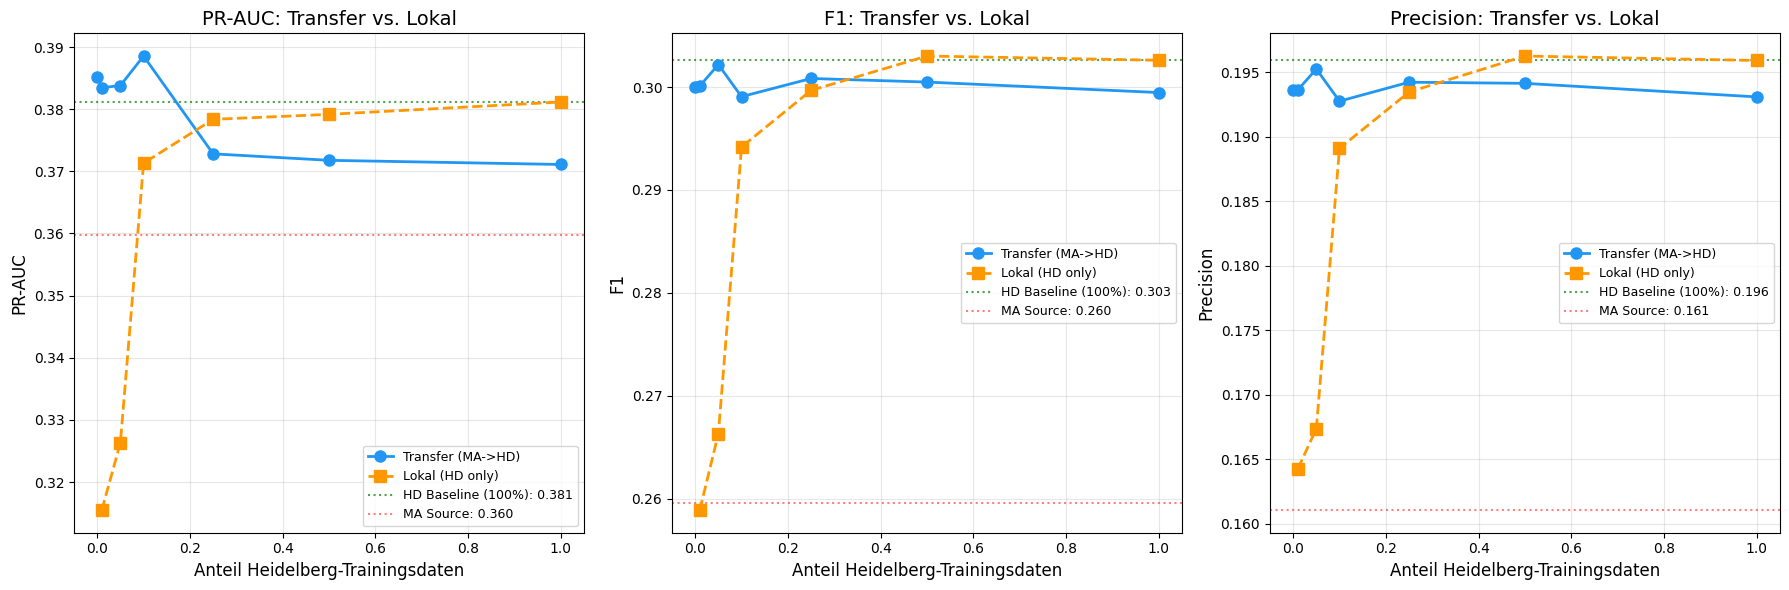

  Gespeichert: /content/drive/MyDrive/BA_Colab/data/v10_transfer_results/v10_transfer_comparison.png


In [24]:
# ══════════════════════════════════════════════════════════════
# Phase 6b — Visualisierung: Transfer vs. Lokal bei variierender Datenmenge
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ["PR-AUC", "F1", "Precision"]

for ax, metric in zip(axes, metrics):
    # Transfer-Linie
    transfer_x = [0.0]  # Zero-Shot
    transfer_y = [zero_shot_result["results"].get("test", {}).get(
        metric.lower().replace("-", "_").replace("pr_auc", "pr_auc"), None
    )]

    # Mapping für Metrik-Key
    key_map = {"PR-AUC": "pr_auc", "F1": "f1", "Precision": "precision"}
    mkey = key_map[metric]

    transfer_x = [0.0]
    transfer_y = [zero_shot_result["results"].get("test", {}).get(mkey)]

    for ratio in sorted(ft_results.keys()):
        transfer_x.append(ratio)
        transfer_y.append(ft_results[ratio]["results"].get("test", {}).get(mkey))

    # Lokal-Linie
    local_x, local_y = [], []
    for ratio in sorted(scarcity_results.keys()):
        local_x.append(ratio)
        local_y.append(scarcity_results[ratio]["results"].get("test", {}).get(mkey))

    ax.plot(transfer_x, transfer_y, 'o-', color='#2196F3', linewidth=2,
            markersize=8, label='Transfer (MA->HD)', zorder=3)
    ax.plot(local_x, local_y, 's--', color='#FF9800', linewidth=2,
            markersize=8, label='Lokal (HD only)', zorder=3)

    # Baseline-Linie (HD 100%)
    baseline_val = baseline_hd_result["results"].get("test", {}).get(mkey)
    if baseline_val is not None:
        ax.axhline(y=baseline_val, color='green', linestyle=':', alpha=0.7,
                    label=f'HD Baseline (100%): {baseline_val:.3f}')

    # Mannheim Source
    ma_val = source_result["results"].get("test", {}).get(mkey)
    if ma_val is not None:
        ax.axhline(y=ma_val, color='red', linestyle=':', alpha=0.5,
                    label=f'MA Source: {ma_val:.3f}')

    ax.set_xlabel("Anteil Heidelberg-Trainingsdaten", fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f"{metric}: Transfer vs. Lokal", fontsize=14)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.05, 1.05)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/v10_transfer_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"  Gespeichert: {RESULTS_DIR}/v10_transfer_comparison.png")


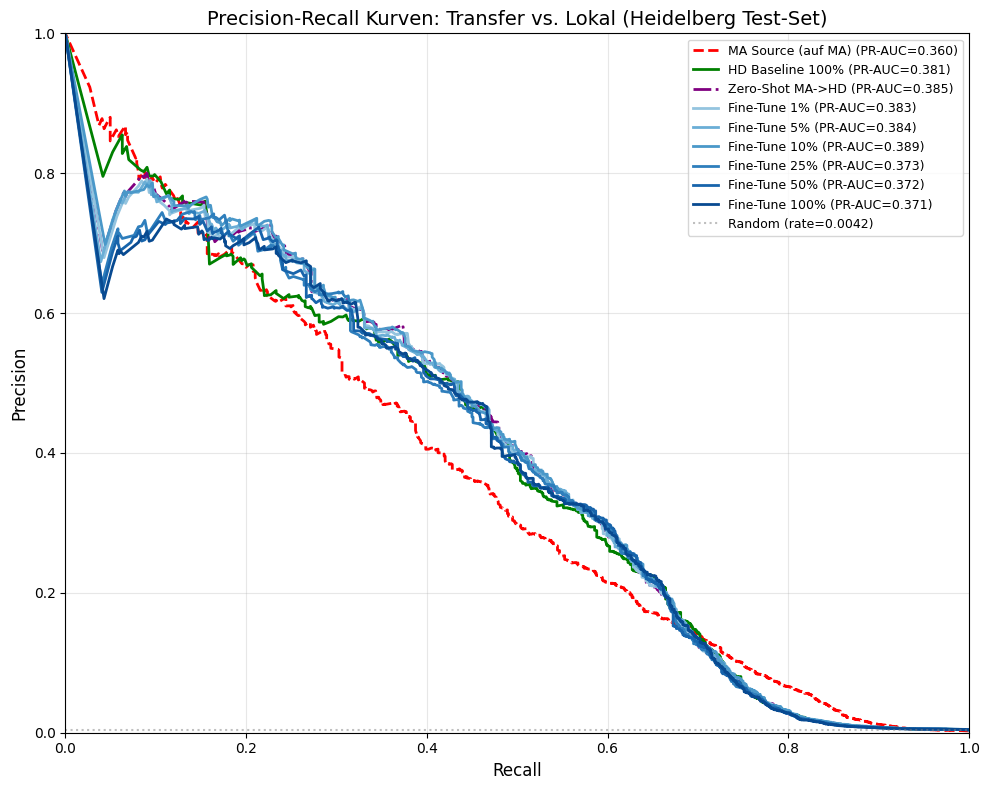

In [25]:
# ══════════════════════════════════════════════════════════════
# Phase 6c — PR-Kurven Vergleich (Testset)
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 8))

def plot_pr_curve(meta_df, label, color, linestyle='-'):
    '''Plottet PR-Kurve für ein Experiment.'''
    test_df = meta_df[meta_df["split"] == "test"].copy()
    y_true  = test_df["label_eval"].isin(["anomal_high", "anomal_low"]).astype(int).values
    y_score = test_df["ae_last_step_score_pct_station"].values

    valid = np.isfinite(y_score)
    if valid.sum() == 0 or len(np.unique(y_true[valid])) < 2:
        return

    precision, recall, _ = precision_recall_curve(y_true[valid], y_score[valid])
    pr_auc = average_precision_score(y_true[valid], y_score[valid])

    ax.plot(recall, precision, linestyle=linestyle, color=color,
            linewidth=2, label=f"{label} (PR-AUC={pr_auc:.3f})")

# Mannheim Source (auf Mannheim-Testdaten)
plot_pr_curve(source_result["meta_all_seq"], "MA Source (auf MA)", "red", "--")

# HD Baseline
plot_pr_curve(baseline_hd_result["meta_all_seq"], "HD Baseline 100%", "green")

# Zero-Shot
plot_pr_curve(zero_shot_result["meta_all_seq"], "Zero-Shot MA->HD", "purple", "-.")

# Beste Fine-Tuning Varianten
colors_ft = plt.cm.Blues(np.linspace(0.4, 0.9, len(ft_results)))
for (ratio, res), color in zip(sorted(ft_results.items()), colors_ft):
    plot_pr_curve(res["meta_all_seq"], f"Fine-Tune {int(ratio*100)}%", color)

# Baseline-Linie
baseline_rate = baseline_hd_result["results"].get("test", {}).get("anomaly_rate_true", 0.003)
ax.axhline(y=baseline_rate, color='gray', linestyle=':', alpha=0.5,
            label=f'Random (rate={baseline_rate:.4f})')

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Kurven: Transfer vs. Lokal (Heidelberg Test-Set)", fontsize=14)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/v10_pr_curves.png", dpi=150, bbox_inches='tight')
plt.show()


---
## Interpretation & Diskussion

**Checkliste für die BA-Diskussion:**

1. **Zero-Shot Ergebnis:** Wie gut performt das Mannheim-Modell direkt auf Heidelberg?
   - Falls PR-AUC > Random-Baseline: Es gibt transferierbares Wissen!
   - Falls PR-AUC ≈ Random: Die Städte sind zu unterschiedlich ohne Anpassung.

2. **Fine-Tuning Kurve:** Ab welchem Datenanteil übertrifft Transfer das lokale Training?
   - Dieser "Break-Even-Punkt" ist die zentrale Erkenntnis für die Forschungsfrage.

3. **Normalisierung als Schlüssel:** War der lokale StandardScaler auf Heidelberg
   entscheidend für den Transfer?

4. **Limitationen:**
   - Pseudo-Labels (kein Ground Truth) -> zirkuläre Evaluation
   - Nur ein Source-Target-Paar -> Generalisierbarkeit unklar
   - Beide Städte nutzen Nextbike -> gleicher Anbieter reduziert Domain Gap

**Für die Ergebnistabelle in der BA:**
Die CSV in `v10_transfer_results.csv` enthält alle Metriken.


In [26]:
# ══════════════════════════════════════════════════════════════
# Zusammenfassung als Dict speichern
# ══════════════════════════════════════════════════════════════
summary = {
    "source_city": cfg.source_city,
    "target_city": cfg.target_city,
    "source_test": source_result["results"].get("test", {}),
    "baseline_hd_test": baseline_hd_result["results"].get("test", {}),
    "zero_shot_test": zero_shot_result["results"].get("test", {}),
    "fine_tune_tests": {
        f"{int(r*100)}pct": res["results"].get("test", {})
        for r, res in ft_results.items()
    },
    "scarcity_tests": {
        f"{int(r*100)}pct": res["results"].get("test", {})
        for r, res in scarcity_results.items()
    },
}

with open(f"{RESULTS_DIR}/v10_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

print(f"✅ Zusammenfassung gespeichert: {RESULTS_DIR}/v10_summary.json")
print(f"\n{'='*70}")
print(f"  V10 TRANSFER-EXPERIMENT ABGESCHLOSSEN")
print(f"{'='*70}")


✅ Zusammenfassung gespeichert: /content/drive/MyDrive/BA_Colab/data/v10_transfer_results/v10_summary.json

  V10 TRANSFER-EXPERIMENT ABGESCHLOSSEN
